Session 3 activity 1

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import load_iris, load_diabetes
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configure plots for better visibility
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load a Titanic dataset directly from a URL
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url_titanic)

# Basic cleanup:
# 1. Drop columns that are unique identifiers or text that a basic model cannot process mathematically.
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, errors='ignore')

# 2. Fill missing 'Age' values with the median age of all passengers.
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# 3. Convert 'Sex' from text ('male'/'female') to numeric (0/1). This is a simple form of encoding.
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# 4. Drop any remaining rows that still have missing values (e.g., if 'Fare' was missing).
titanic_df.dropna(inplace=True)

print("Titanic Data (first 5 rows):")
print(titanic_df.head())
print("\nData Info:")
titanic_df.info()

Titanic Data (first 5 rows):
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


/tmp/ipykernel_19052/626608649.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)


In [3]:
# Define features (X) by dropping the target column
X_titanic = titanic_df.drop('Survived', axis=1)

# Define target (y) by selecting only the target column
y_titanic = titanic_df['Survived']

print("\nFeatures (X):")
print(X_titanic.head(2))
print("\nTarget (y):")
print(y_titanic.head(2))


Features (X):
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833

Target (y):
0    0
1    1
Name: Survived, dtype: int64


In [4]:
# Split the data
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)

print(f"\nTraining set shape: X={X_train_titanic.shape}, y={y_train_titanic.shape}")
print(f"Testing set shape: X={X_test_titanic.shape}, y={y_test_titanic.shape}")


Training set shape: X=(712, 6), y=(712,)
Testing set shape: X=(179, 6), y=(179,)


In [5]:
# Create a Decision Tree Classifier model
# max_depth restricts how deep the tree can grow to prevent overfitting
clf_titanic = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model using the training data ONLY
clf_titanic.fit(X_train_titanic, y_train_titanic)

print("\nDecision Tree Classifier model trained successfully.")


Decision Tree Classifier model trained successfully.


In [6]:
# Make predictions
y_pred_titanic = clf_titanic.predict(X_test_titanic)

# Display first 10 predictions vs actual values
print("\nFirst 10 Predictions:", y_pred_titanic[:10])
print("First 10 Actual Values:", y_test_titanic[:10].values)


First 10 Predictions: [0 0 0 0 0 0 1 1 0 0]
First 10 Actual Values: [0 0 1 0 1 1 1 0 0 0]


In [7]:
# Evaluate the model
accuracy_titanic = accuracy_score(y_test_titanic, y_pred_titanic)
print(f"\nModel Accuracy: {accuracy_titanic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_titanic, y_pred_titanic, target_names=['Did not Survive', 'Survived']))


Model Accuracy: 0.7542

Classification Report:
                 precision    recall  f1-score   support

Did not Survive       0.76      0.88      0.82       110
       Survived       0.75      0.55      0.63        69

       accuracy                           0.75       179
      macro avg       0.75      0.72      0.72       179
   weighted avg       0.75      0.75      0.75       179



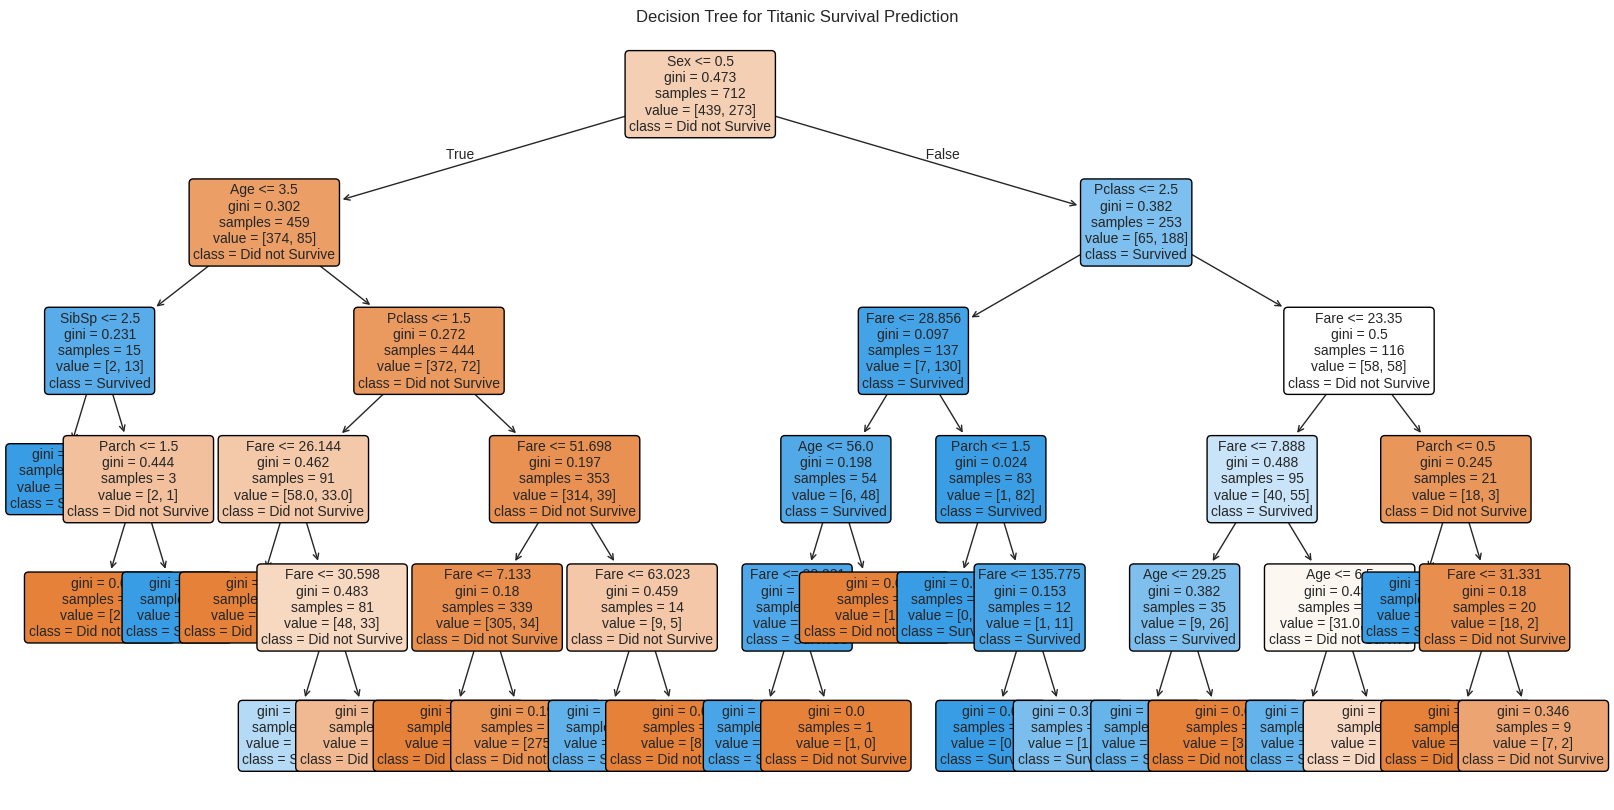

In [8]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(clf_titanic,
          feature_names=X_titanic.columns,
          class_names=['Did not Survive', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()